# 🧩 Heurística Shelf First Fit para o Problema de Empacotamento 2D

Este projeto tem como objetivo desenvolver e implementar uma **heurística de construção Shelf First Fit** para resolver o **Problema de Empacotamento Bidimensional (2D Bin Packing Problem)**, amplamente estudado na área de otimização e logística.

## 📦 Descrição do Problema

Dado um conjunto de itens retangulares, cada um com largura e altura conhecidas, o desafio consiste em empacotá-los dentro de um recipiente bidimensional de dimensões fixas, **sem sobreposição**, buscando **maximizar o aproveitamento do espaço disponível**.

O problema pertence à classe dos **NP-difíceis**, tornando heurísticas construtivas uma alternativa eficiente para gerar boas soluções em tempo computacional reduzido.

## 📚 Heurística Shelf First Fit

A heurística **Shelf First Fit** organiza o empacotamento da seguinte forma:

- O recipiente é dividido em **prateleiras (shelves)** horizontais  
- Cada item é colocado na **primeira prateleira disponível** onde ele cabe  
- Caso o item não caiba em nenhuma prateleira existente, uma **nova prateleira é criada**  
- A altura da prateleira é definida pelo **item mais alto nela alocado**

---



In [ ]:
from google.colab import files
uploaded = files.upload()


###**Importação das bibliotecas**

In [ ]:
import csv
import copy
import random
import matplotlib.pyplot as plt
import os

# interactive visualization
from ipywidgets import IntSlider, interact
from ipywidgets import Dropdown, Button, VBox, Output

###**Definição das classes:**

In [ ]:
class Item:
    def __init__(self, width, height, id=None):
        self.width = width
        self.height = height
        self.id = id

        # position in the bin
        self.x = None
        self.y = None

        self.shelf = None # shelf where the item was placed

In [ ]:
class Shelf:
    def __init__(self, y_position, max_width, height):
        self.y = y_position
        self.max_width = max_width # maximum allowed width (bin width)
        self.height = height # height of the shelf (defined by the tallest item in it)
        self.used_width = 0 # width already used by placed items
        self.items = [] #List of items placed on this shelf

    def can_place(self, item):
        return (
            # check if adding the item would exceed the shelf width
            self.used_width + item.width <= self.max_width

            # check if the item is not taller than the shelf
            and item.height <= self.height
        )

    def place_item(self, item):
        # the item is placed immediately after the last occupied space
        item.x = self.used_width
        item.y = self.y
        item.shelf = self # store a reference to the shelf where the item was placed

        self.items.append(item) # add the item to the shelf's item list
        self.used_width += item.width # update the used width of the shelf

In [ ]:
class Bin:
    def __init__(self, width, height):
        self.width = width
        self.height = height
        self.shelves = [] # list of shelves inside the bin
        self.current_height = 0 # total height occupied by shelves

    def can_create_shelf(self, item):

        """
        Checks if there is enough vertical space
        to create a new shelf for the given item.
        """
        return self.current_height + item.height <= self.height

    def create_shelf(self, item):
        # create a new shelf at the current height
        shelf = Shelf(
            y_position=self.current_height,
            max_width=self.width,
            height=item.height   #define a altura da shelf
        )

        shelf.place_item(item)
        self.shelves.append(shelf) # add the shelf to the bin
        self.current_height += shelf.height # update the used height of the bin

###**Carregamento de itens:**

In [ ]:
def load_items_from_csv(file_name):
    items = []

    with open(file_name, newline="", encoding="latin-1") as csvfile:
        reader = csv.DictReader(csvfile)

        print("📌 Colunas detectadas:", reader.fieldnames)

        for i, row in enumerate(reader, start=1):

            # detect columns
            width = (
                row.get("width")
                or row.get("largura")
                or row.get("w")
                or row.get("W")
            )

            height = (
                row.get("height")
                or row.get("altura")
                or row.get("h")
                or row.get("H")
            )

            if width is None or height is None:
                raise ValueError(
                    f"CSV inválido: não foi possível detectar largura/altura na linha {i}"
                )

            # add items to the list
            items.append(
                Item(
                    width=float(width),
                    height=float(height),
                    id=i  # automatically assigned item ID
                )
            )

    return items

In [ ]:
def shelf_first_fit_with_history(items, bin_width, bin_height):
    bin = Bin(bin_width, bin_height) # create an empty bin with given dimensions
    history = [] # list to store snapshots of the bin state

    for item in items:
        placed = False

        # try to place the item in existing shelves
        for shelf in bin.shelves:
            if shelf.can_place(item):
                shelf.place_item(item)
                placed = True
                break

        # if the item was not placed, try to create a new shelf
        if not placed:
            if bin.can_create_shelf(item):
                bin.create_shelf(item)
            else:
                raise ValueError(
                    f"Item {item.id} não cabe no bin ({bin_width} x {bin_height})"
                )

        # store a copy of the current bin state for visualization
        history.append(copy.deepcopy(bin))

    return bin, history

**Visualização:**

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors


def plot_step_pretty(
    initial_bin,
    title="",
    subtitle="",
    highlight_shelf_waste=False
):
    fig, ax = plt.subplots(figsize=(11, 6))

    ax.add_patch(
        patches.Rectangle(
            (0, 0),
            initial_bin.width,
            initial_bin.height,
            linewidth=2.5,
            edgecolor="#333333",
            facecolor="none"
        )
    )

    color_cycle = list(mcolors.TABLEAU_COLORS.values())
    used_height = 0

    for s_idx, shelf in enumerate(initial_bin.shelves):
        shelf_color = color_cycle[s_idx % len(color_cycle)]
        used_height = max(used_height, shelf.y + shelf.height)

        # Fundo da shelf
        ax.add_patch(
            patches.Rectangle(
                (0, shelf.y),
                initial_bin.width,
                shelf.height,
                facecolor=shelf_color,
                alpha=0.08,
                edgecolor="none"
            )
        )

        # Linha da shelf
        ax.plot(
            [0, initial_bin.width],
            [shelf.y, shelf.y],
            linestyle="--",
            linewidth=1,
            color="#666666"
        )

        for item in shelf.items:
            ax.add_patch(
                patches.Rectangle(
                    (item.x, item.y),
                    item.width,
                    item.height,
                    facecolor=shelf_color,
                    edgecolor="#333333",
                    linewidth=1.5
                )
            )

            ax.text(
                item.x + item.width / 2,
                item.y + item.height / 2,
                f"Item {item.id}\n({item.width}×{item.height})",
                ha="center",
                va="center",
                fontsize=9,
                color="white",
                weight="bold"
            )

            if highlight_shelf_waste:
                vertical_waste = shelf.height - item.height
                if vertical_waste > 0:
                    ax.add_patch(
                        patches.Rectangle(
                            (item.x, item.y + item.height),
                            item.width,
                            vertical_waste,
                            facecolor="none",
                            edgecolor=shelf_color,
                            hatch="..",
                            linewidth=1.0
                        )
                    )

        if highlight_shelf_waste:
            remaining_width = initial_bin.width - shelf.used_width
            if remaining_width > 0:
                ax.add_patch(
                    patches.Rectangle(
                        (shelf.used_width, shelf.y),
                        remaining_width,
                        shelf.height,
                        facecolor="none",
                        edgecolor=shelf_color,
                        hatch="\\\\",
                        linewidth=1.2
                    )
                )

    if used_height < initial_bin.height:
        ax.add_patch(
            patches.Rectangle(
                (0, used_height),
                initial_bin.width,
                initial_bin.height - used_height,
                facecolor="none",
                edgecolor="#AA0000",
                hatch="///",
                linewidth=1.2
            )
        )


    ax.set_xlim(0, initial_bin.width)
    ax.set_ylim(0, initial_bin.height)
    ax.set_aspect("equal")
    ax.invert_yaxis()

    ax.set_xlabel("Largura")
    ax.set_ylabel("Altura")

    fig.suptitle(title, fontsize=16, weight="bold", y=0.98)
    if subtitle:
        ax.set_title(subtitle, fontsize=11, color="#555555", pad=12)

    ax.grid(False)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [ ]:
def interactive_animation(history, instance_name=""):
    max_step = len(history)

    def show_step(step):
        plot_step_pretty(
            history[step - 1],
            title="Shelf First Fit – Construção da Solução",
            subtitle=f"Etapa {step} de {max_step}",
            highlight_shelf_waste=(step == max_step)
        )

    interact(
        show_step,
        step=IntSlider(
            min=1,
            max=max_step,
            step=1,
            value=1,
            description="Etapa"
        )
    )

In [ ]:
def list_csv_files():
    return sorted([f for f in os.listdir() if f.endswith(".csv")])

output = Output()

dropdown = Dropdown(
    options=list_csv_files(),
    description="CSV:",
    disabled=False
)

button = Button(
    description="Carregar e Executar",
    button_style="success"
)

In [ ]:
def run_from_selected_csv(_):
    output.clear_output()

    with output:
        csv_file = dropdown.value
        print(f"📄 Arquivo selecionado: {csv_file}")

        items = load_items_from_csv(csv_file)

        print("✅ Itens carregados:")
        for item in items:
            print(f"Item {item.id} | w={item.width}, h={item.height}")

        initial_bin, history = shelf_first_fit_with_history(
            items,
            bin_width=10,
            bin_height=12
        )


        initial_waste = total_waste(initial_bin)

        print("\n🔹 SOLUÇÃO INICIAL – Shelf First Fit")
        print(f"Desperdício inicial: {initial_waste}")

        interactive_animation(history, instance_name=csv_file)


button.on_click(run_from_selected_csv)

VBox([dropdown, button, output])

# 🔍 Heurística de Busca Local para o Empacotamento 2D em Shelves

Após a construção de uma solução inicial por meio da heurística **Shelf First Fit**, é aplicada uma **heurística de busca local** com o objetivo de **reduzir o desperdício de espaço** e melhorar a qualidade do empacotamento.

A busca local atua sobre uma solução **viável**, promovendo pequenas modificações estruturais que possam levar a soluções progressivamente melhores.

---

## 🎯 Objetivo da Busca Local

O principal objetivo da busca local é **minimizar o desperdício total de área**, considerando:

- Espaço não utilizado acima da última prateleira (desperdício global)
- Espaço lateral não ocupado dentro das prateleiras
- Espaço vertical desperdiçado devido à diferença entre a altura da prateleira e a altura dos itens

A busca local **não permite sobreposição de itens** e **respeita as regras do modelo de shelves**, mantendo a viabilidade da solução em todas as etapas.

---

## 🔄 Estrutura da Vizinhança

A vizinhança da solução é explorada por meio de dois tipos principais de movimentos:

### 🔁 1. Troca de Itens entre Prateleiras

Consiste em:
- Selecionar dois itens pertencentes a prateleiras diferentes
- Tentar trocar suas alocações
- Aceitar a troca caso ambos os itens caibam nas novas prateleiras e a solução permaneça viável

---

### 🔃 2. Reorganização de Prateleiras

Neste movimento:
- Todos os itens de uma prateleira são removidos
- Os itens são reinseridos em uma nova ordem
- Avalia-se se a reorganização melhora o aproveitamento do espaço

Esse tipo de movimento é mais custoso computacionalmente, porém permite **alterações estruturais mais profundas** na solução.

---

## A busca é encerrada quando um **ótimo local** é alcançado.



In [ ]:
def total_waste(initial_bin):
    used_area = 0
    for shelf in initial_bin.shelves:
        for item in shelf.items:
            used_area += item.width * item.height

    bin_area = initial_bin.width * initial_bin.height
    return bin_area - used_area

In [ ]:
def try_swap_items(initial_bin, shelf_i, shelf_j, item_i, item_j):
    new_bin = copy.deepcopy(initial_bin)

    s1 = new_bin.shelves[shelf_i]
    s2 = new_bin.shelves[shelf_j]

    i1 = s1.items[item_i]
    i2 = s2.items[item_j]

    # Remove
    s1.items.pop(item_i)
    s2.items.pop(item_j)

    s1.used_width -= i1.width
    s2.used_width -= i2.width

    # Testa encaixe cruzado
    if s1.can_place(i2) and s2.can_place(i1):
        s1.place_item(i2)
        s2.place_item(i1)
        return new_bin

    return None

In [ ]:
def local_search_swap(initial_bin):
    current = initial_bin
    current_cost = total_waste(current)

    history = [("Inicial", current_cost)]
    improved = True
    iteration = 0

    while improved:
        improved = False
        iteration += 1

        for i in range(len(current.shelves)):
            for j in range(i + 1, len(current.shelves)):
                for ii in range(len(current.shelves[i].items)):
                    for jj in range(len(current.shelves[j].items)):

                        candidate = try_swap_items(
                            current, i, j, ii, jj
                        )

                        if candidate is not None:
                            cost = total_waste(candidate)

                            if cost < current_cost:
                                current = candidate
                                current_cost = cost
                                history.append(
                                    (f"Iteração {iteration}", current_cost)
                                )
                                improved = True
                                break
                    if improved: break
                if improved: break
            if improved: break

    return current, history

In [ ]:
csv_file_for_local_search = "realista.csv"
print(f"Carregando itens de um arquivo padrão para a busca local: {csv_file_for_local_search}")
items_for_local_search = load_items_from_csv(csv_file_for_local_search)

# Usando as dimensões de bin consistentes com a configuração original
bin_width_for_local_search = 10
bin_height_for_local_search = 12

initial_bin, history_sff = shelf_first_fit_with_history(
    items_for_local_search,
    bin_width_for_local_search,
    bin_height_for_local_search
)
initial_waste = total_waste(initial_bin)
print(f"Desperdício inicial (calculado para a busca local): {initial_waste}")


final_bin, log = local_search_swap(initial_bin)
final_waste = total_waste(final_bin)

print("\n🔹 SOLUÇÃO FINAL – Após Busca Local")
print(f"Desperdício final: {final_waste}")
print(f"Ganho total: {initial_waste - final_waste}")

Carregando itens de um arquivo padrão para a busca local: realista.csv
📌 Colunas detectadas: ['w', 'h']
Desperdício inicial (calculado para a busca local): 43.0

🔹 SOLUÇÃO FINAL – Após Busca Local
Desperdício final: 43.0
Ganho total: 0.0


In [ ]:
print("\n📈 Evolução da busca local:")
for step, waste in log:
    print(f"{step}: desperdício = {waste}")


📈 Evolução da busca local:
Inicial: desperdício = 43.0


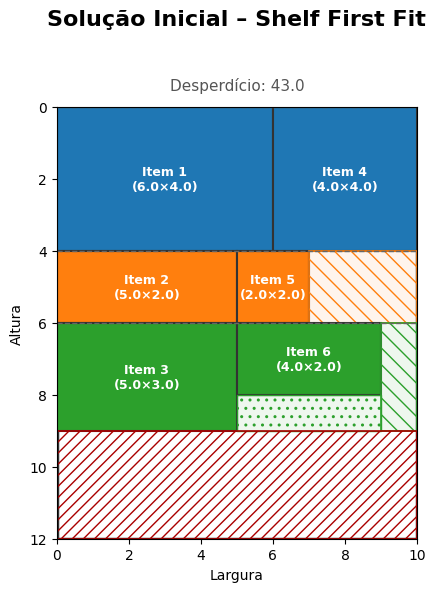

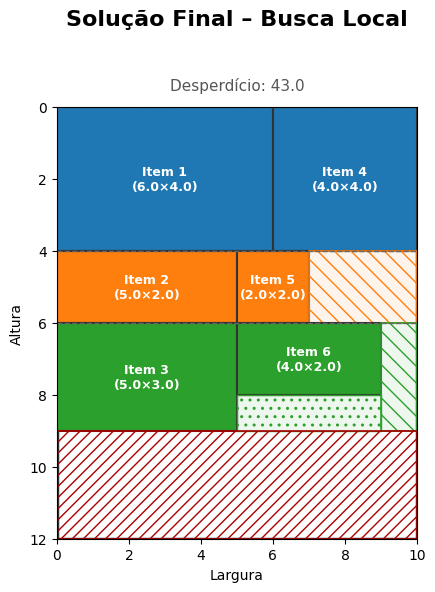

In [ ]:
plot_step_pretty(
    initial_bin,
    title="Solução Inicial – Shelf First Fit",
    subtitle=f"Desperdício: {initial_waste}",
    highlight_shelf_waste=True
)

plot_step_pretty(
    final_bin,
    title="Solução Final – Busca Local",
    subtitle=f"Desperdício: {final_waste}",
    highlight_shelf_waste=True
)
